In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

import importlib

import tensorboard
%load_ext tensorboard

import math

from torch.utils.tensorboard import SummaryWriter
import datetime

import os, sys
module_path = os.path.abspath(os.path.join('..', "source"))
if module_path not in sys.path:
    sys.path.append(module_path)

import pbr_dataset
import models
import train

import torchmetrics
import flip_loss

from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

## Tensorboard
This command gets you tensorboard with all the metrics and data. Run it in a command line in the notebook directory if you want it on its own tab. 
### Warning
I would recommend just running the command in a command prompt because I don't know how to close the server from a notebook.

In [2]:
tensorboard.notebook.list()

Known TensorBoard instances:
  - port 6006: logdir ../experiments/pbr_compression (started 0:05:54 ago; pid 23368)


In [14]:
tensorboard.notebook.start("--logdir ../experiments/pbr_compression --samples_per_plugin images=500")

## Loading the PBR textures
For now I'm just going to assume that each pbr material has a texture folder and there are three textures named 'arm.jpg', 'albedo.jpg' and 'normal.jpg'.

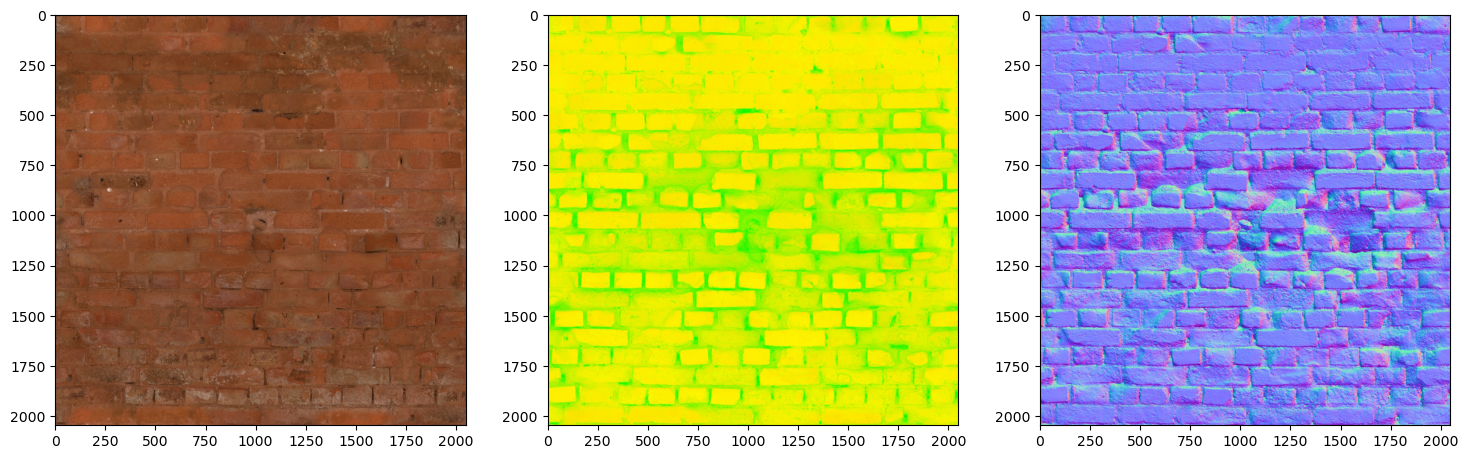

In [2]:
materials_path = "../assets/materials/"
material_name = "broken_brick_wall"
material_textures_path = materials_path + material_name + "/textures/"
ext = ".jpg"

albedo = Image.open(material_textures_path + "albedo" + ext).convert("RGB")
arm = Image.open(material_textures_path + "arm" + ext).convert("RGB")
normal = Image.open(material_textures_path + "normal" + ext).convert("RGB")

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(albedo)
axes[1].imshow(arm)
axes[2].imshow(normal)

plt.show()

In [30]:
importlib.reload(models)
importlib.reload(pbr_dataset)

if 'writer' in globals():
    writer.close()
    del writer
    
writer = SummaryWriter("../experiments/pbr_compression/neutex_siren" + "TEST" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))

hidden_features = 64
hidden_layers = 3
first_omega = 20
hidden_omega = 15
sidelength = 1024
embedding_channels = 4
batch_size = 512

model = models.SirenTex(sidelength, embedding_channels, out_features=3*3, hidden_features=hidden_features, hidden_layers=hidden_layers, 
                        first_omega_0=first_omega, hidden_omega_0=hidden_omega).cuda()

dataset = pbr_dataset.PBRDataset(albedo, arm, normal, sidelength=sidelength)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

#writer.add_graph(model.siren_net, dataset.input_features_tensor)
writer.add_text("model info", f"sidelength: {sidelength}\nembedding channels: {embedding_channels}\nbatch size: {batch_size}\nhidden features: {hidden_features}\nhidden layers: {hidden_layers}\nfirst omega: {first_omega}\nhidden omega: {hidden_omega}")

current_epoch = 0

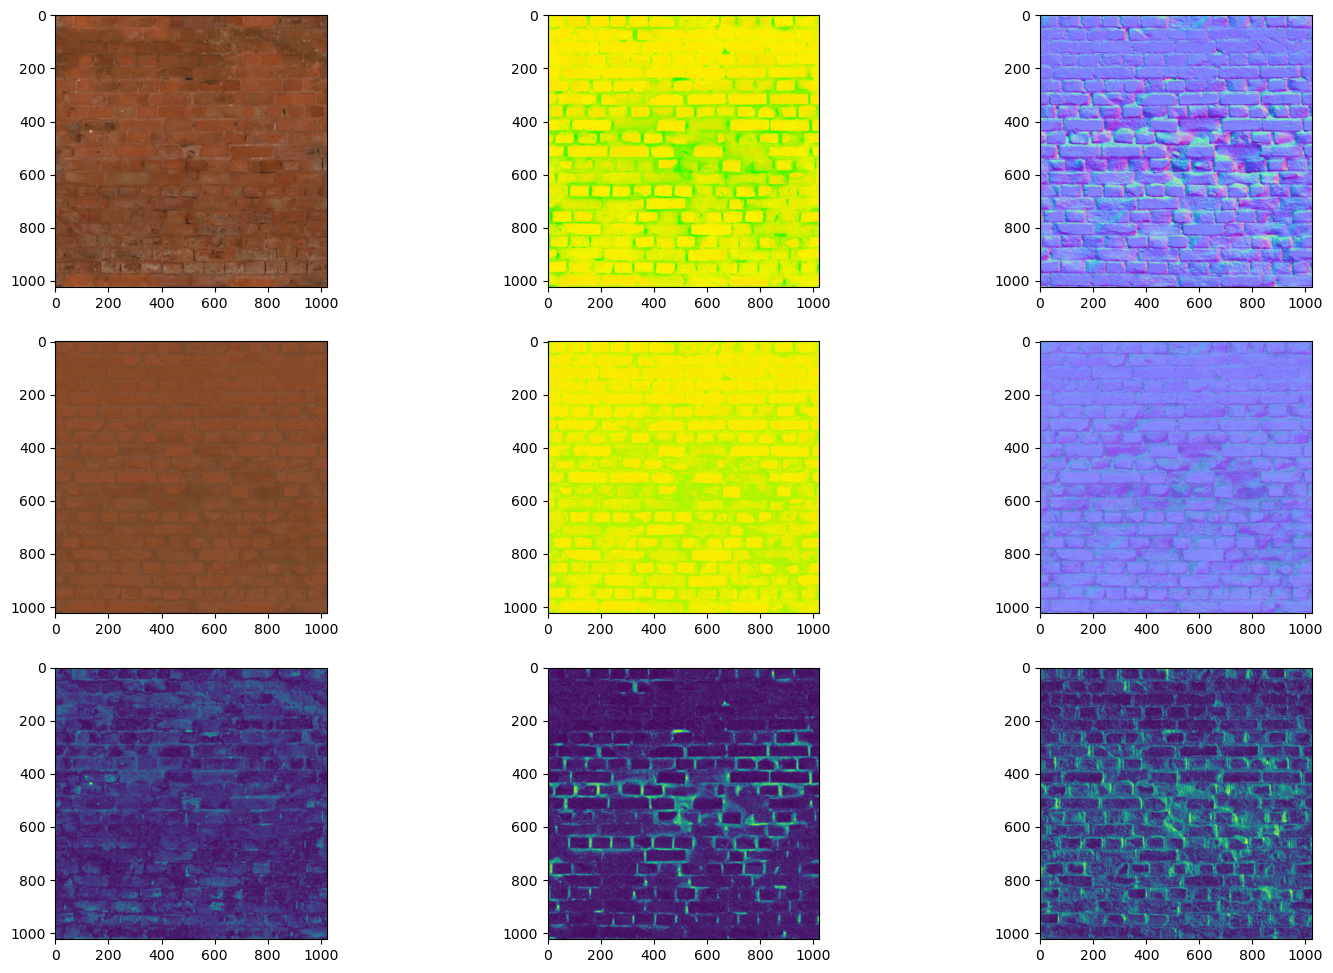

epoch:   2
loss: 0.043891 [  512/1048576]
loss: 0.040738 [10752/1048576]


KeyboardInterrupt: 

In [31]:
importlib.reload(train)

optimizer = torch.optim.Adam(lr=1e-4, params=model.parameters())

loss_fn = torch.nn.L1Loss()

num_epochs = 20

train.training_loop(model, optimizer, dataloader, writer, loss_fn, num_epochs, current_epoch, 20)
current_epoch = current_epoch + num_epochs